[back-customer-churn-dataset](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/bank_customer_churn_prediction.csv")
df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
print("============ INFO >>>")
print(df.info())

print("============ DESCRIBE >>>")
print(df.describe())

print("============ CHURN >>>")
print(df['churn'].value_counts(normalize=True))

============ INFO >>>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
============ DESCRIBE >>>
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10

### Column 시각화
- **kind** : 그래프 종류 지정
    - **'line'**: line plot (default)
    - **'bar'**: vertical bar plot
    - **'barh'**: horizontal bar plot
    - **'hist'**: histogram
    - **'box'**: boxplot
    - **'kde'**: Kernel Density Estimation plot
    - **'pie'**: pie plot
    - **'scatter'**: scatter plot

### matplotlib 한글 설정 (MAC)
    - .venv > lib > python3.13 > site-packages > matplotlib > mpl-data > matplotlibrc
    - ## : 설명 , # : 설정 → 원하는 설정은 # 해제후 값 변경
    - 한국어 사용 설정 : `font.family` 값 변경 “Apple SD Gothic Neo”, `axes.unicode_minus`: False

In [4]:
category_cols = ['gender', 'country', 'credit_card', 'active_member']
numeric_cols = ["age", "balance", "tenure", "credit_score", "estimated_salary", "products_number"]

col_names = {
    'customer_id' : '고객 id',
    'credit_score' : '고객 신용점수',
    'country' : '국적',
    'gender' : '성별 (Female/Male)',
    'age' : '나이',
    'tenure' : '은행과 거래한 기간(년 단위)',
    'balance' : '계좌 잔액',
    'products_number' : '고객이 보유한 은행 상품 개수',
    'credit_card' : '신용카드 보유 여부 (0/1)',
    'active_member' : '활성 고객 여부 (0/1)',
    'estimated_salary' : '고객 추정 연봉',
    'churn' : '이탈 여부 (0=유지/1=이탈)'
}

df.columns, col_names

(Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
        'balance', 'products_number', 'credit_card', 'active_member',
        'estimated_salary', 'churn'],
       dtype='object'),
 {'customer_id': '고객 id',
  'credit_score': '고객 신용점수',
  'country': '국적',
  'gender': '성별 (Female/Male)',
  'age': '나이',
  'tenure': '은행과 거래한 기간(년 단위)',
  'balance': '계좌 잔액',
  'products_number': '고객이 보유한 은행 상품 개수',
  'credit_card': '신용카드 보유 여부 (0/1)',
  'active_member': '활성 고객 여부 (0/1)',
  'estimated_salary': '고객 추정 연봉',
  'churn': '이탈 여부 (0=유지/1=이탈)'})

In [5]:
# 결측치 확인 -> 결측치 없음.
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

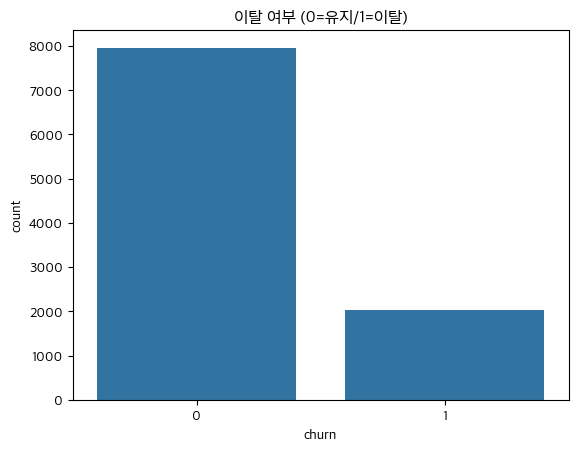

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=df)
plt.title(col_names['churn'])
plt.show()

**  gender
Male      5457
Female    4543
Name: count, dtype: int64
**  country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


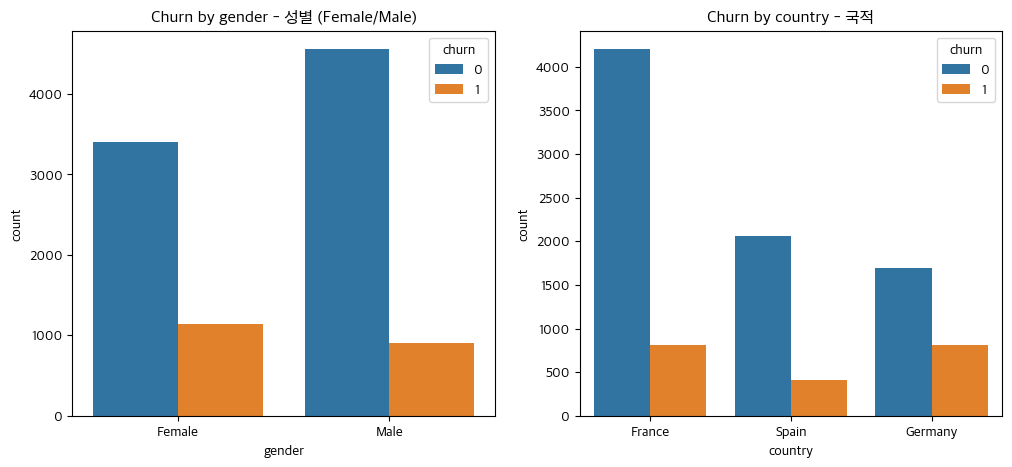

**  credit_card
1    7055
0    2945
Name: count, dtype: int64
**  active_member
1    5151
0    4849
Name: count, dtype: int64


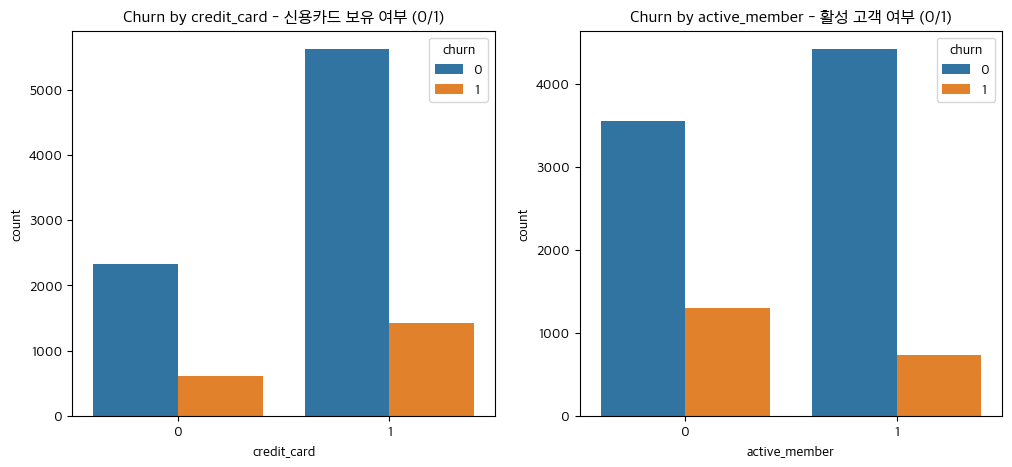

In [16]:
for i in list(range(0, len(category_cols), 2)):
    is_one_col = i + 1 >= len(category_cols)
    left_col = category_cols[i]
    left_data = df[left_col].value_counts()
    
    plt.figure(figsize=(12,5))
    
    print("** ", left_data)

    plt.subplot(1,2,1)
    sns.countplot(x=left_col, hue='churn', data=df)
    plt.title(f"Churn by {left_col} - {col_names[left_col]}")
    
    if not is_one_col:
        right_col = category_cols[i+1]
        right_data = df[right_col].value_counts()
        print("** ", right_data)

        plt.subplot(1,2,2)
        sns.countplot(x=right_col, hue='churn', data=df)
        plt.title(f"Churn by {right_col} - {col_names[right_col]}")
    
    # plt.tight_layout()
    plt.show()

/var/folders/by/sbz15vxn1xz8499rjvlm_ctm0000gn/T/ipykernel_43586/1047782718.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['age'], shade=True)


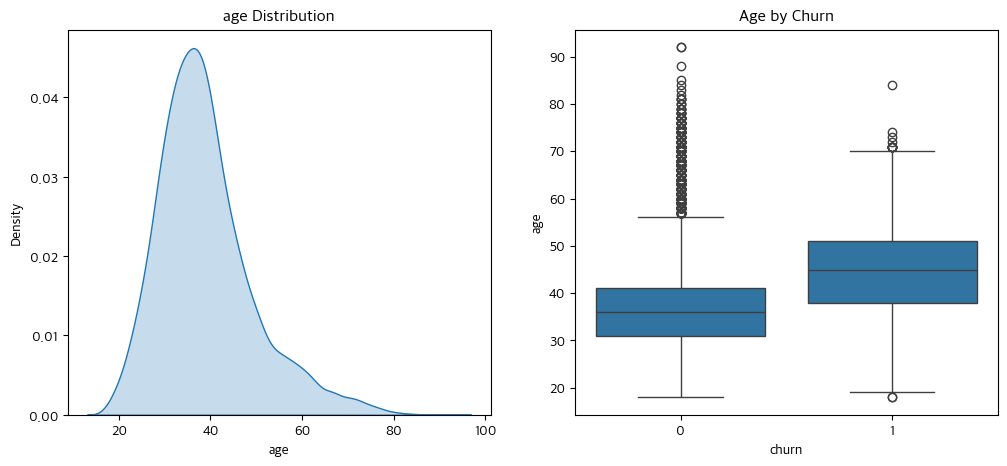

In [14]:
# AGE ====================== 
# boxplot 그래프를 통해서 이탈(churn=1) 고객은 유지(churn=0) 고객보다 연령대가 명확하게 더 높는 것을 알 수 있음.
# 중앙값(median) = blue box y 위치가 0보다 1이 더 높다.
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.kdeplot(df['age'], shade=True)
plt.title("age Distribution")
    
plt.subplot(1,2,2)
sns.boxplot(x='churn', y='age', data=df)
plt.title("Age by Churn")
plt.show()

/var/folders/by/sbz15vxn1xz8499rjvlm_ctm0000gn/T/ipykernel_43586/1240335195.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


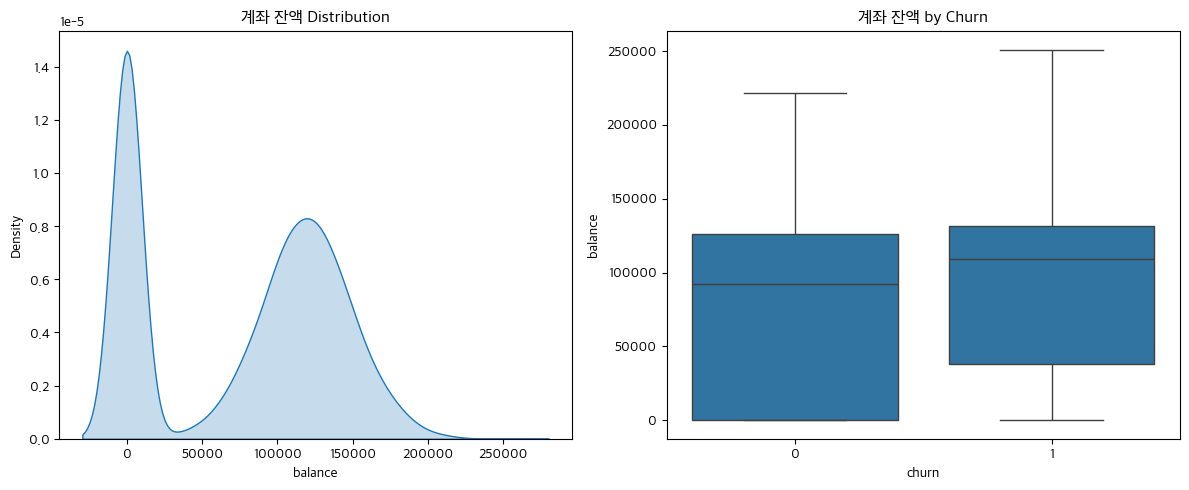

/var/folders/by/sbz15vxn1xz8499rjvlm_ctm0000gn/T/ipykernel_43586/1240335195.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


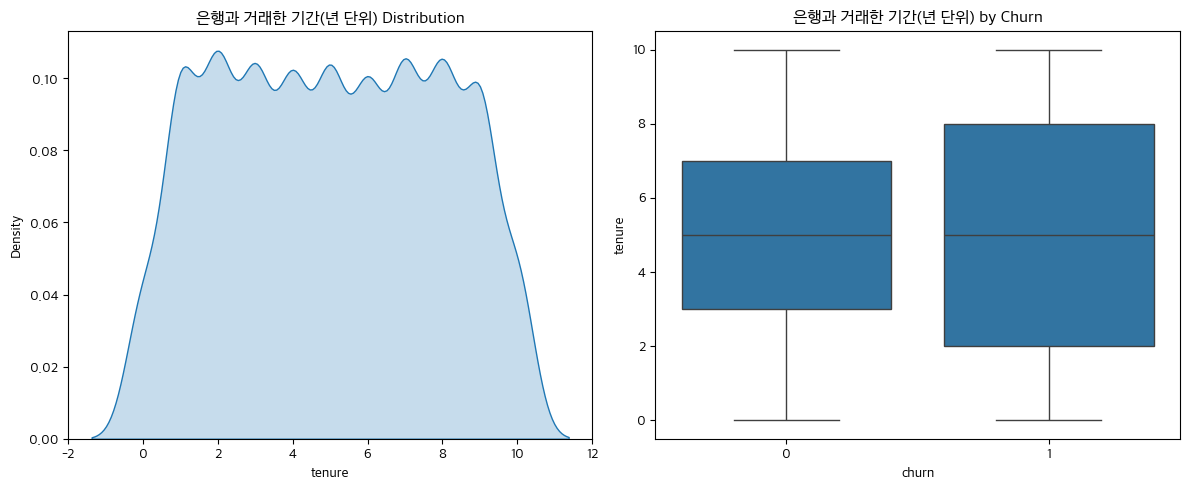

/var/folders/by/sbz15vxn1xz8499rjvlm_ctm0000gn/T/ipykernel_43586/1240335195.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


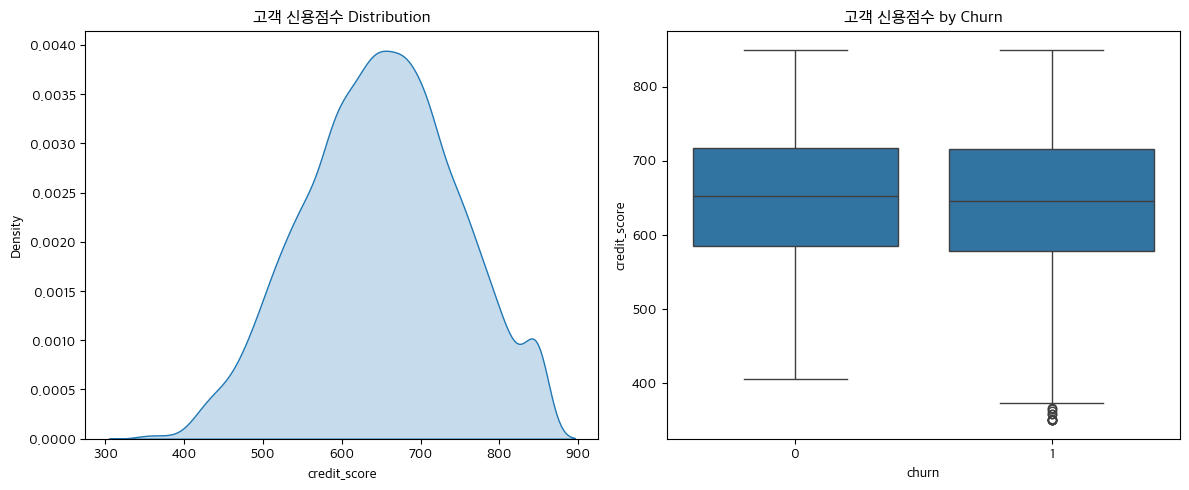

/var/folders/by/sbz15vxn1xz8499rjvlm_ctm0000gn/T/ipykernel_43586/1240335195.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


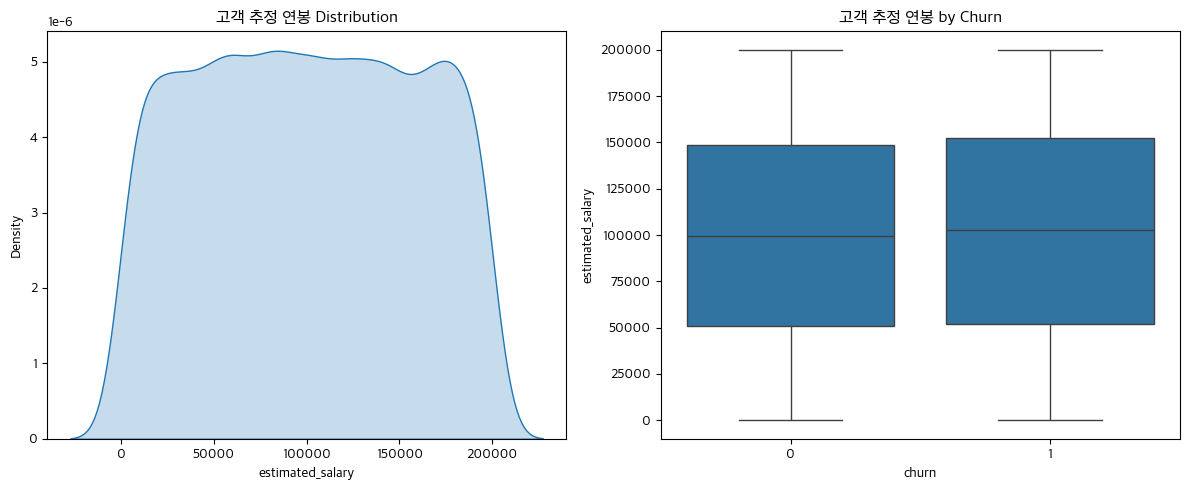

/var/folders/by/sbz15vxn1xz8499rjvlm_ctm0000gn/T/ipykernel_43586/1240335195.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


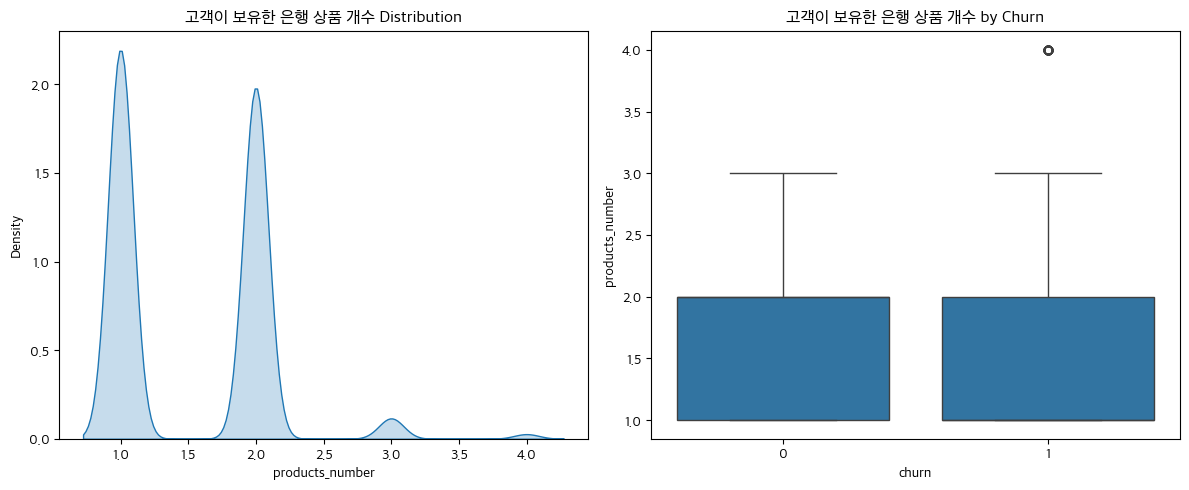

In [18]:
temp_numeric_cols = numeric_cols.copy()
temp_numeric_cols.remove('age')
for col in temp_numeric_cols:
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.kdeplot(df[col], shade=True)
    plt.title(f"{col_names[col]} Distribution")
    
    plt.subplot(1,2,2)
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f"{col_names[col]} by Churn")

    plt.tight_layout()
    plt.show()

Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary', 'churn'],
      dtype='object')
                  credit_score       age    tenure   balance  products_number  \
credit_score          1.000000 -0.003965  0.000842  0.006268         0.012238   
age                  -0.003965  1.000000 -0.009997  0.028308        -0.030680   
tenure                0.000842 -0.009997  1.000000 -0.012254         0.013444   
balance               0.006268  0.028308 -0.012254  1.000000        -0.304180   
products_number       0.012238 -0.030680  0.013444 -0.304180         1.000000   
credit_card          -0.005458 -0.011721  0.022583 -0.014858         0.003183   
active_member         0.025651  0.085472 -0.028362 -0.010084         0.009612   
estimated_salary     -0.001384 -0.007201  0.007784  0.012797         0.014204   
churn                -0.027094  0.285323 -0.014001  0.118533        -0.047820   

                  credit_car

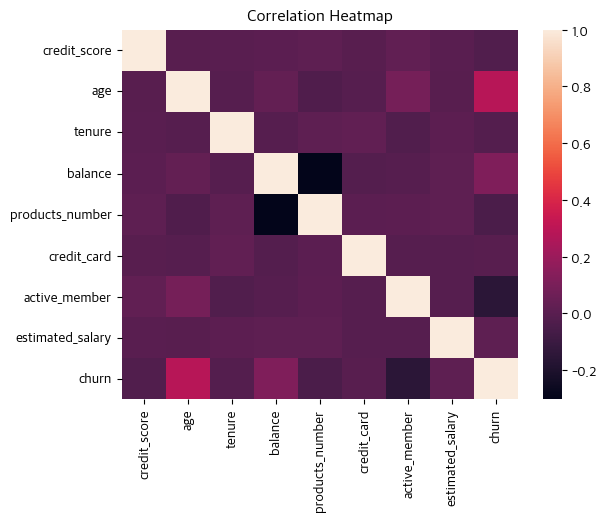

In [12]:
# 식별자 ID 의미 없음 
# 문자열 칼럼 제거
df_num = df.drop(columns=['customer_id', 'country', 'gender'])
print(df_num.columns)
# corr() = DataFrame의 컬럼 간 상관관계를 숫자로 계산하는 함수
corr = df_num.corr()
sns.heatmap(corr, annot=False)
print(corr)
plt.title("Correlation Heatmap")
plt.show()

# 상관관계
# 각 칼럼들끼리 선형 관계만 비교한다.

# feature끼리 상관 낮음 → 중복 없음 → 좋음
# churn과 feature 상관 낮음 → 단선형 패턴 없음 → 나쁜 것이 아니라 원래 churn 구조가 비선형이라는 뜻